In [56]:
import torch
import numpy as np
import random

def set_seed(seed=42):
    """Set the seed for all random generators (for reproducibility)"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # for multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Call the function
set_seed(5)

# Loading Dataset

In [57]:
import pandas as pd
import numpy as np

# Load the dataset from csv
full_dataset = pd.read_csv("dataset.csv")

# Drop missing values
full_dataset = full_dataset.dropna()

print(full_dataset.head())



   id  Gender   Age           City Profession  Academic Pressure  \
0   2    Male  33.0  Visakhapatnam    Student                5.0   
1   8  Female  24.0      Bangalore    Student                2.0   
2  26    Male  31.0       Srinagar    Student                3.0   
3  30  Female  28.0       Varanasi    Student                3.0   
4  32  Female  25.0         Jaipur    Student                4.0   

   Work Pressure  CGPA  Study Satisfaction  Job Satisfaction  \
0            0.0  8.97                 2.0               0.0   
1            0.0  5.90                 5.0               0.0   
2            0.0  7.03                 5.0               0.0   
3            0.0  5.59                 2.0               0.0   
4            0.0  8.13                 3.0               0.0   

      Sleep Duration Dietary Habits   Degree  \
0          5-6 hours        Healthy  B.Pharm   
1          5-6 hours       Moderate      BSc   
2  Less than 5 hours        Healthy       BA   
3          7-8

In [58]:
# Display details for each column
for col, dtype in zip(full_dataset.columns, full_dataset.dtypes):
    print(f"{col} ({str(dtype)}): {full_dataset[col].nunique()} unique values")


id (int64): 27898 unique values
Gender (str): 2 unique values
Age (float64): 34 unique values
City (str): 52 unique values
Profession (str): 14 unique values
Academic Pressure (float64): 6 unique values
Work Pressure (float64): 3 unique values
CGPA (float64): 332 unique values
Study Satisfaction (float64): 6 unique values
Job Satisfaction (float64): 5 unique values
Sleep Duration (str): 5 unique values
Dietary Habits (str): 4 unique values
Degree (str): 28 unique values
Have you ever had suicidal thoughts ? (str): 2 unique values
Work/Study Hours (float64): 13 unique values
Financial Stress (float64): 5 unique values
Family History of Mental Illness (str): 2 unique values
Depression (int64): 2 unique values


In [59]:
# Statistical data for each column
print(full_dataset.describe())


                  id           Age  Academic Pressure  Work Pressure  \
count   27898.000000  27898.000000       27898.000000   27898.000000   
mean    70442.953402     25.822174           3.141336       0.000430   
std     40642.015063      4.905651           1.381462       0.043994   
min         2.000000     18.000000           0.000000       0.000000   
25%     35040.750000     21.000000           2.000000       0.000000   
50%     70689.000000     25.000000           3.000000       0.000000   
75%    105824.750000     30.000000           4.000000       0.000000   
max    140699.000000     59.000000           5.000000       5.000000   

               CGPA  Study Satisfaction  Job Satisfaction  Work/Study Hours  \
count  27898.000000        27898.000000      27898.000000      27898.000000   
mean       7.656160            2.943974          0.000681          7.156570   
std        1.470708            1.361122          0.044397          3.707598   
min        0.000000            0.00

# Data Pre-Processing

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


# Filter to only students (for consistency)
dataset = full_dataset[full_dataset["Profession"] == "Student"].reset_index(drop=True)

# NOTE: Drop unnecessary variables (This is up for debate!)
# Here's my general reasoning:
# - id: Just a counter, not a relevant value
# - City: This didn't really have any strong effect in testing, and if we want a general model, it doesn't really make sense to include
# - Profession, Work Pressure, Job Satisfaction: Since we're working with students only, there were only like three data points for these values,
#     so I just sorted to only include students, and dropped the profession-based variables
dataset = dataset.drop(columns=["id", "City", "Profession", "Work Pressure", "Job Satisfaction"])

# Remove "Others" responses from Sleep Duration and Dietary Habits
dataset = dataset[dataset["Sleep Duration"] != "Others"].copy()
dataset = dataset[dataset["Dietary Habits"] != "Others"].copy()
sleep_mapping = {
    'Less than 5 hours': 1,
    '5-6 hours': 2,
    '7-8 hours': 3,
    'More than 8 hours': 4
}

# Add interaction terms
dataset["Pressure_x_Sleep"] = dataset["Academic Pressure"] * dataset["Sleep Duration"].map(sleep_mapping)
dataset["Pressure_x_Stress"] = dataset["Academic Pressure"] * dataset["Financial Stress"]
dataset["Stress_x_Sleep"] = dataset["Financial Stress"] * dataset["Sleep Duration"].map(sleep_mapping)
dataset["Pressure_x_Satisfaction"] = dataset["Academic Pressure"] * dataset["Study Satisfaction"]

interaction_terms = ["Pressure_x_Sleep", "Pressure_x_Stress", "Stress_x_Sleep", "Pressure_x_Satisfaction"]

# Separate the target variable (y)
X = dataset.drop('Depression', axis=1)
y = dataset['Depression']

# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Group columns by data type
numeric_features = [
    'Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction', 'Work/Study Hours', 'Financial Stress'
] + interaction_terms
categorical_features = [
    'Gender', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 
    'Family History of Mental Illness'
]

# Column transformer will convert data into usable numeric values for models to use
preprocessor = ColumnTransformer(
    transformers=[
        # Numerical values are already the correct type, so just scale to unit variance
        ('num', StandardScaler(), numeric_features),
        # Categorical variables are one-hot encoded, and then drop the first of each category (so we don't have two variables each for True/False values)
        ('cat', OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features.copy())
    ]
)

# Apply the preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Original X_train shape: {X_train.shape}")
print(f"Processed X_train shape: {X_train_processed.shape}")

Original X_train shape: (22269, 16)
Processed X_train shape: (22269, 45)


# Functions/Tools

## Model Evaluation Tools

In [61]:
from sklearn.metrics import accuracy_score, average_precision_score, brier_score_loss, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, matthews_corrcoef, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
import torch
import torch.nn as nn

def evaluate_model(model, X_test, y_test, name="Model", show_plots=True, threshold=0.5):
    """Evaluate the provided model. Calculates a variety of metrics and (optionally) displays results"""
    metrics = {"Model": name}
    y_proba = None
    y_score = None

    # Handle PyTorch models
    if isinstance(model, nn.Module):
        model.eval()
        # Convert to tensor
        if not torch.is_tensor(X_test):
            if hasattr(X_test, "toarray"):
                X_test_tensor = torch.tensor(X_test.toarray(), dtype=torch.float32)
            else:
                X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        else:
            X_test_tensor = X_test

        with torch.no_grad():
            outputs = model(X_test_tensor)
            if outputs.shape[1] == 1:
                y_proba = outputs.squeeze().cpu().numpy()
            else:
                y_proba = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        
        y_score = y_proba
        metrics["ROC-AUC"] = roc_auc_score(y_test, y_proba)
        metrics["Brier_Score"] = brier_score_loss(y_test, y_proba)
        y_pred = (y_proba >= threshold).astype(int)

    elif hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        y_score = y_proba
        metrics["ROC-AUC"] = roc_auc_score(y_test, y_proba)
        metrics["Brier_Score"] = brier_score_loss(y_test, y_proba)
        
        # Apply the threshold
        y_pred = (y_proba >= threshold).astype(int)
    
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
        metrics["ROC-AUC"] = roc_auc_score(y_test, y_score)
        metrics["Brier_Score"] = None
        
        # Fallback to standard prediction if no probabilities
        y_pred = model.predict(X_test)

    else:
        y_pred = model.predict(X_test)
        metrics["ROC-AUC"] = None
        metrics["Brier_Score"] = None

    # Calculate other prediction metrics
    metrics["Accuracy"] = accuracy_score(y_test, y_pred)
    metrics["Precision"] = precision_score(y_test, y_pred, zero_division=0)
    metrics["Recall"] = recall_score(y_test, y_pred, zero_division=0)
    metrics["F1_Score"] = f1_score(y_test, y_pred, zero_division=0)
    metrics["MCC"] = matthews_corrcoef(y_test, y_pred)
    metrics["AP"] = average_precision_score(y_test, y_score) if y_score is not None else None

    # Display the results
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred))
    if metrics["ROC-AUC"] is not None:
        print(f"ROC-AUC: {metrics['ROC-AUC']:.4f}")
    if metrics["Brier_Score"] is not None:
        print(f"Brier Score: {metrics['Brier_Score']:.4f}")
    print(f"MCC: {metrics['MCC']:.4f}")

    if show_plots:
        # Display the confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Not Depressed", "Depressed"]
        )
        disp.plot(cmap="Blues")
        plt.title(f"{name} Confusion Matrix")
        
        if y_proba is not None:
            # Display the ROC curve
            fpr, tpr, _ = roc_curve(y_test, y_proba)

            # Compute Precision-Recall
            precision, recall, _ = precision_recall_curve(y_test, y_proba)
            ap = average_precision_score(y_test, y_proba)

            fig, axes = plt.subplots(1, 2, figsize=(12, 5))

            # ROC Curve
            axes[0].plot(fpr, tpr, label=f"AUC = {metrics["ROC-AUC"]:.3f}")
            axes[0].plot([0, 1], [0, 1], linestyle="--")
            axes[0].set_xlabel("False Positive Rate")
            axes[0].set_ylabel("True Positive Rate")
            axes[0].set_title(f"{name} ROC Curve")
            axes[0].legend()
        
            # Precision-Recall Curve
            baseline = sum(y_test) / len(y_test)
            axes[1].plot(recall, precision, label=f"AP = {ap:.3f}")
            axes[1].hlines(baseline, 0, 1, linestyles="--", label="Baseline")
            axes[1].set_xlabel("Recall")
            axes[1].set_ylabel("Precision")
            axes[1].set_title(f"{name} Precision-Recall Curve")
            axes[1].legend()

            plt.tight_layout()

        plt.show()

    return metrics

def show_feature_importance(model, preprocessor, top_n=10):
    feature_names = preprocessor.get_feature_names_out()
    coefficients = model.coef_[0]

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients
    })

    feature_importance = feature_importance.sort_values(
        by="Coefficient",
        ascending=False
    )

    print(f"\n--- Top {top_n} Features Increasing Risk ---")
    print(feature_importance.head(top_n).to_string(index=False))

    print(f"\n--- Top {top_n} Features Decreasing Risk ---")
    print(feature_importance.tail(top_n).to_string(index=False))

def cross_validate_model(model, X, y, cv=5, scoring="roc_auc", name="Model"):
    """Perform K-fold cross validation, returning the list of scores"""
    scores = cross_val_score(model, X, y, cv=cv, scoring=scoring)
    print(f"\n--- {name} {cv}-Fold Cross-Validation ({scoring}) ---")
    print(f"Individual Fold Scores: {['{:.4f}'.format(s) for s in scores]}")
    print(f"Mean Score: {scores.mean():.4f}")
    print(f"Standard Deviation: +/- {scores.std():.4f}")
    
    return scores

def evaluate_sparsity(model) -> int:
    coef = model.coef_[0]
    non_zero = np.sum(coef != 0)
    total = len(coef)
    print(f"Non-zero features: {non_zero}")
    print(f"Total features: {total}")
    print(f"Sparsity: {100 * (1 - non_zero/total):.2f}% features removed")
    return non_zero


import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_gridsearch_param(
    grid_search,
    param_name: str,
    use_log_scale: bool = True,
    selected_value: float = None
):
    """Plot score vs. a hyperparameter (to select best value for a minimal model)"""
    results = pd.DataFrame(grid_search.cv_results_)

    param_col = f"param_{param_name}"
    if param_col not in results:
        raise ValueError(f"Parameter '{param_name}' not found.")

    x = results[param_col].astype(float)
    y = results["mean_test_score"]
    std = results["std_test_score"]

    # Sort for clean plotting
    order = np.argsort(x)
    x, y, std = x.iloc[order], y.iloc[order], std.iloc[order]

    # Best point
    best_idx = y.idxmax()
    best_x = results.loc[best_idx, param_col]
    best_y = results.loc[best_idx, "mean_test_score"]
    best_std = results.loc[best_idx, "std_test_score"]

    upper = best_y + best_std
    lower = best_y - best_std

    plt.figure()

    # Main curve
    plt.plot(x, y, marker="o", label="Mean CV Score")

    # Highlight best point
    plt.scatter(best_x, best_y, color="red", zorder=3, label="Best")

    # Horizontal std band
    plt.axhspan(lower, upper, alpha=0.15, label="±1 std (best)")

    if selected_value is not None:
        selected_value = float(selected_value)
        selected_y = np.interp(selected_value, x, y)  # approximate y-position

        plt.scatter(
            selected_value,
            selected_y,
            color="green",
            s=100,
            zorder=4,
            label=f"Selected {param_name} = {selected_value:.4f}"
        )
        plt.axvline(selected_value, color="red", linestyle="--", alpha=0.5)

    plt.xlabel(param_name)
    plt.ylabel("Mean Test Score")
    plt.title(f"{param_name} vs Cross-Validated Score")
    plt.grid(True)

    if use_log_scale:
        plt.xscale("log")

    plt.legend()
    plt.tight_layout()
    plt.show()


In [62]:
def find_best_threshold(y_true, y_proba, target_recall=None, target_precision=None):
    """Find threshold based on target recall or precision"""
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    thresholds = np.append(thresholds, 1.0)  # Fix array size difference

    # Target recall
    if target_recall is not None:
        valid_idx = np.where(recall >= target_recall)[0]
        if len(valid_idx) == 0:
            return None
        
        best_idx = valid_idx[np.argmax(precision[valid_idx])]

    # Target precision
    elif target_precision is not None:
        valid_idx = np.where(precision >= target_precision)[0]
        if len(valid_idx) == 0:
            return None
        
        best_idx = valid_idx[np.argmax(recall[valid_idx])]

    else:
        raise ValueError("Provide either target_recall or target_precision")

    return {
        "threshold": thresholds[best_idx],
        "precision": precision[best_idx],
        "recall": recall[best_idx]
    }

# Logistic Regression

## Standard (All predictors)


--- Standard LR 5-Fold Cross-Validation (roc_auc) ---
Individual Fold Scores: ['0.9204', '0.9255', '0.9193', '0.9166', '0.9201']
Mean Score: 0.9204
Standard Deviation: +/- 0.0029

--- Full (45 features) Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.80      0.84      0.82      2310
           1       0.88      0.85      0.87      3258

    accuracy                           0.85      5568
   macro avg       0.84      0.84      0.84      5568
weighted avg       0.85      0.85      0.85      5568

ROC-AUC: 0.9235
Brier Score: 0.1092
MCC: 0.6838


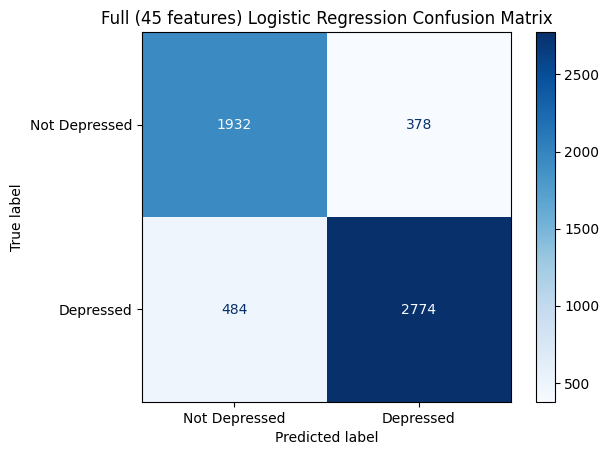

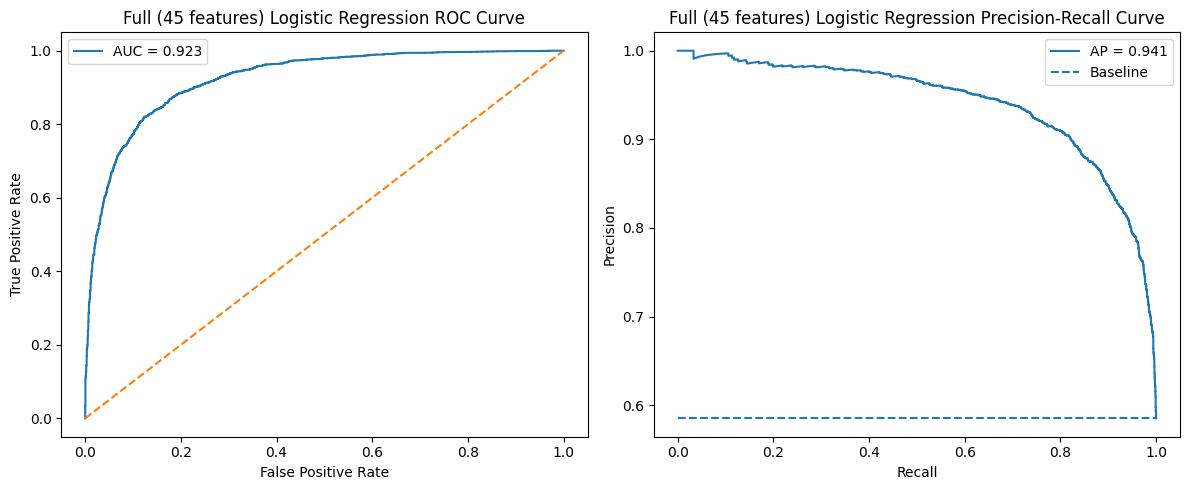


--- Top 10 Features Increasing Risk ---
                                       Feature  Coefficient
cat__Have you ever had suicidal thoughts ?_Yes     2.474382
                        num__Academic Pressure     1.299410
                 cat__Dietary Habits_Unhealthy     1.090514
                         num__Financial Stress     0.745524
                  cat__Dietary Habits_Moderate     0.479837
         cat__Sleep Duration_Less than 5 hours     0.447810
                         num__Work/Study Hours     0.441024
     cat__Family History of Mental Illness_Yes     0.243957
                               cat__Degree_LLM     0.216745
                               cat__Degree_BSc     0.164693

--- Top 10 Features Decreasing Risk ---
                              Feature  Coefficient
              num__Study Satisfaction    -0.187751
                       cat__Degree_MA    -0.209304
                       cat__Degree_BA    -0.210536
                      cat__Degree_BHM    -0.215254
   

In [63]:
from sklearn.linear_model import LogisticRegression

# Build the logistic regression model ("balanced" means classes are given equal weight)
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Train the model
log_reg.fit(X_train_processed, y_train)

# Do cross-validation to check consistency
cv_scores = cross_validate_model(log_reg, X_train_processed, y_train, cv=5, name="Standard LR")

# Evaluate the model
evaluate_model(log_reg, X_test_processed, y_test, f"Full ({len(log_reg.coef_[0])} features) Logistic Regression")

# Rank features by importance
show_feature_importance(log_reg, preprocessor)


## Sparse (Using Lasso Regression)

Running Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


e:\Programming\Repositories\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\Programming\Repositories\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Optimal 'C' within margin: 0.0112


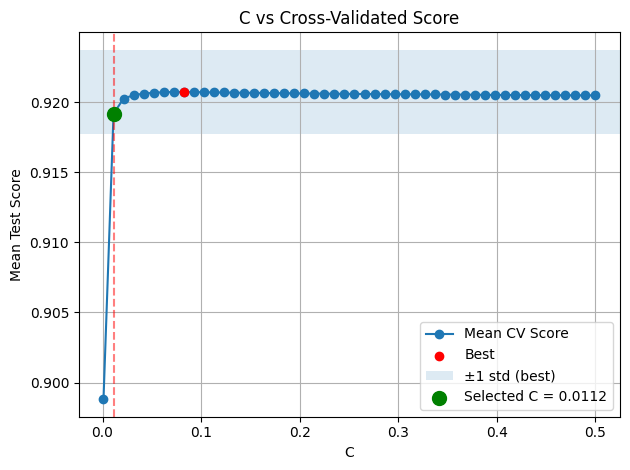

e:\Programming\Repositories\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\Programming\Repositories\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
e:\Programming\Repositories\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of

Non-zero features: 14
Total features: 45
Sparsity: 68.89% features removed


e:\Programming\Repositories\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\Programming\Repositories\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
e:\Programming\Repositories\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of


--- Sparse (14 features) LR 5-Fold Cross-Validation (roc_auc) ---
Individual Fold Scores: ['0.9186', '0.9250', '0.9184', '0.9159', '0.9180']
Mean Score: 0.9192
Standard Deviation: +/- 0.0031
Threshold Details: (Threshold = 0.3891 | Precision = 0.8468 | Recall = 0.9012

--- Sparse (14 features) Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.77      0.81      2310
           1       0.85      0.90      0.87      3258

    accuracy                           0.85      5568
   macro avg       0.85      0.84      0.84      5568
weighted avg       0.85      0.85      0.85      5568

ROC-AUC: 0.9230
Brier Score: 0.1098
MCC: 0.6823


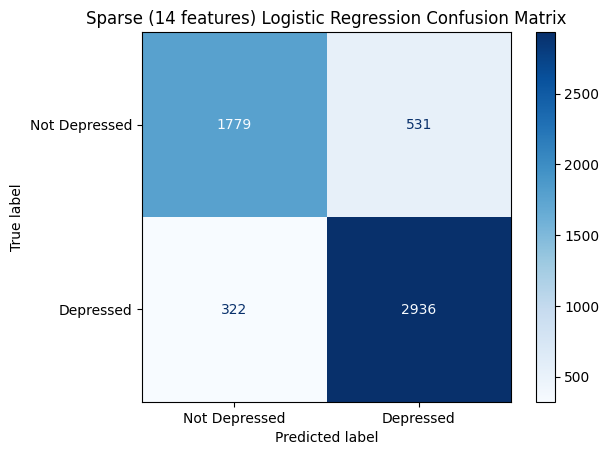

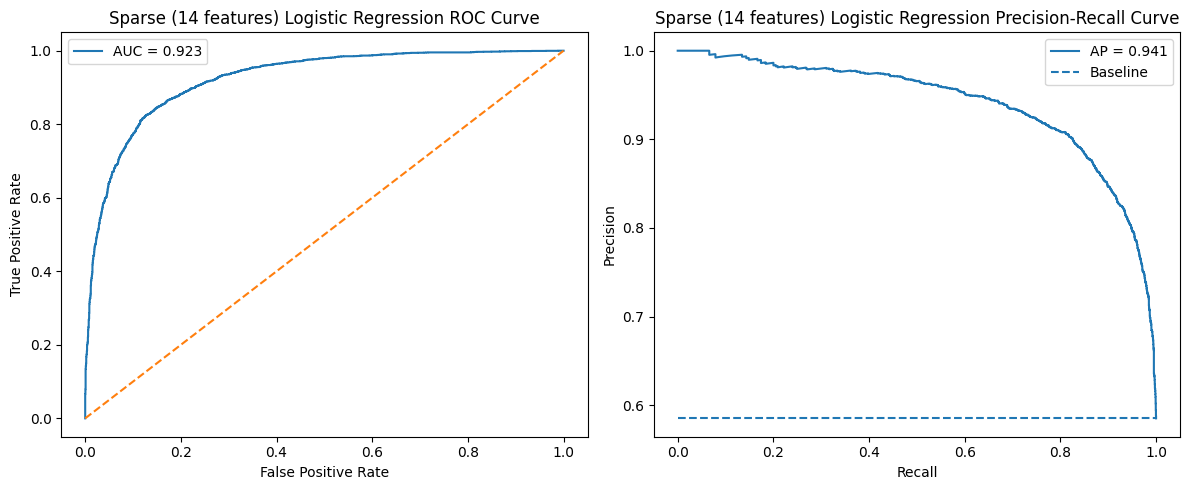


--- Top 10 Features Increasing Risk ---
                                       Feature  Coefficient
cat__Have you ever had suicidal thoughts ?_Yes     2.260496
                        num__Academic Pressure     1.031386
                 cat__Dietary Habits_Unhealthy     0.725933
                         num__Financial Stress     0.682555
                         num__Work/Study Hours     0.389646
         cat__Sleep Duration_Less than 5 hours     0.216300
                  cat__Dietary Habits_Moderate     0.148394
     cat__Family History of Mental Illness_Yes     0.097964
                        num__Pressure_x_Stress     0.094479
                                     num__CGPA     0.042763

--- Top 10 Features Decreasing Risk ---
                              Feature  Coefficient
                  cat__Degree_M.Pharm     0.000000
                   cat__Degree_M.Tech     0.000000
                      cat__Degree_PhD     0.000000
                      cat__Degree_MHM     0.000000
   

In [64]:
from sklearn.model_selection import GridSearchCV

# Tuning flag - If performance is bad, disable this! (model will use pre-tuned C value from my testing)
TUNE_C = True
DEFAULT_C = 0.02

if TUNE_C:
    # Build the base LR model to evaluate C values
    base_log_reg = LogisticRegression(
        penalty='l1',
        solver="saga",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    )

    # Test all values of C using 5-fold cross validation (ROC-AUC) to evaluate
    hyper_parameter_grid = {
        'C': np.linspace(0.001, 0.5, 50)
    }
    grid_search = GridSearchCV(
        estimator=base_log_reg,
        param_grid=hyper_parameter_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    print("Running Hyperparameter Tuning...")
    grid_search.fit(X_train_processed, y_train)

    # Keep the best model
    results = pd.DataFrame(grid_search.cv_results_)
    best_index = results['mean_test_score'].idxmax()
    best_score = results.loc[best_index, 'mean_test_score']

    acceptable_threshold = best_score - results['std_test_score']

    # Choose the simplest model within the acceptable threshold
    good_models = results[results["mean_test_score"] >= acceptable_threshold]
    optimal_C = good_models['param_C'].astype(float).min()
    print(f"Optimal 'C' within margin: {optimal_C:.4f}")
    plot_gridsearch_param(grid_search, "C", selected_value=optimal_C, use_log_scale=False)
else:
    # If tuning is disabled, use value from testing
    optimal_C = DEFAULT_C

# Now, train a model with the optimal C
log_reg_sparse = LogisticRegression(
    penalty='l1', 
    solver="saga",
    C=optimal_C,
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
log_reg_sparse.fit(X_train_processed, y_train)

# Evaluate sparsity after Lasso
num_features = evaluate_sparsity(log_reg_sparse)

# Do cross-validation to check consistency
cv_scores = cross_validate_model(log_reg_sparse, X_train_processed, y_train, cv=5, name=f"Sparse ({num_features} features) LR")

# Find the best threshold for evaluation (Used to weight TP/FN)
y_proba_test = log_reg_sparse.predict_proba(X_test_processed)[:, 1]
threshold_result = find_best_threshold(y_test, y_proba_test, target_recall=0.90)  # Catch 90% of true positives (avoid false negatives)
print(f"Threshold Details: (Threshold = {threshold_result["threshold"]:.4f} | Precision = {threshold_result["precision"]:.4f} | Recall = {threshold_result["recall"]:.4f}")

# Evaluate the model
evaluate_model(log_reg_sparse, X_test_processed, y_test, f"Sparse ({num_features} features) Logistic Regression", threshold=threshold_result["threshold"])

# Rank features by importance
show_feature_importance(log_reg_sparse, preprocessor)

## Without Suicide Indication (Avoiding leakage)
Because suicide is so closely aligned with depression, including it could be considered data leakage ("Are you suicidal?" is basically the same as "Are you depressed?")

Below is the same logistic regression model trained without the suicide survey point

In [65]:
# Also split a dataset without the suicidal tendency variable (could be leaking?)
categorical_features_no_suicide = categorical_features.copy()
categorical_features_no_suicide.remove('Have you ever had suicidal thoughts ?')

X_train_no_suicide = X_train.drop(columns=["Have you ever had suicidal thoughts ?"])
X_test_no_suicide = X_test.drop(columns=["Have you ever had suicidal thoughts ?"])

preprocessor_no_suicide = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features_no_suicide)
    ]
)

X_train_processed_no_suicide = preprocessor_no_suicide.fit_transform(X_train_no_suicide)
X_test_processed_no_suicide = preprocessor_no_suicide.transform(X_test_no_suicide)

Running Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


e:\Programming\Repositories\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\Programming\Repositories\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Optimal 'C' within margin: 0.0112


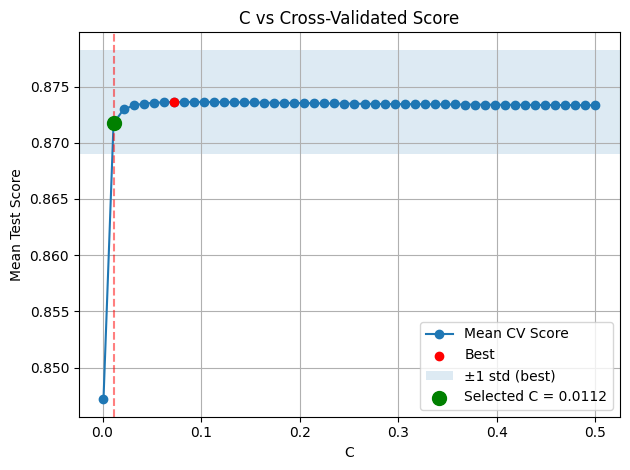

e:\Programming\Repositories\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\Programming\Repositories\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
e:\Programming\Repositories\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of

Non-zero features: 12
Total features: 44
Sparsity: 72.73% features removed


e:\Programming\Repositories\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\Programming\Repositories\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
e:\Programming\Repositories\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of


--- Sparse (12 features) LR (No Suicide) 5-Fold Cross-Validation (roc_auc) ---
Individual Fold Scores: ['0.8761', '0.8787', '0.8679', '0.8699', '0.8661']
Mean Score: 0.8717
Standard Deviation: +/- 0.0049
Threshold Details: (Threshold = 0.3319 | Precision = 0.7755 | Recall = 0.9002

--- Sparse (12 features) LR (No Suicide) Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.63      0.71      2310
           1       0.78      0.90      0.83      3258

    accuracy                           0.79      5568
   macro avg       0.80      0.77      0.77      5568
weighted avg       0.79      0.79      0.78      5568

ROC-AUC: 0.8678
Brier Score: 0.1466
MCC: 0.5623


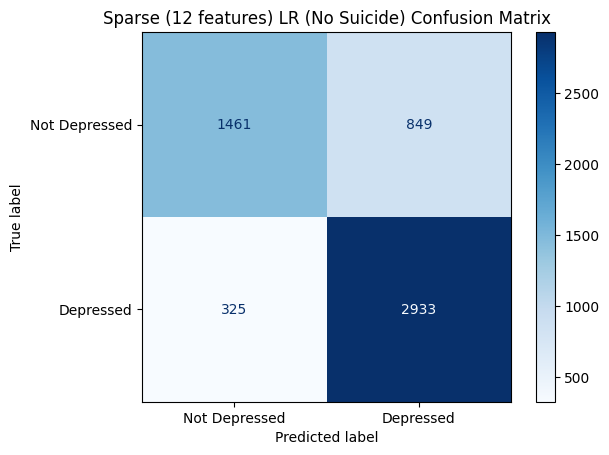

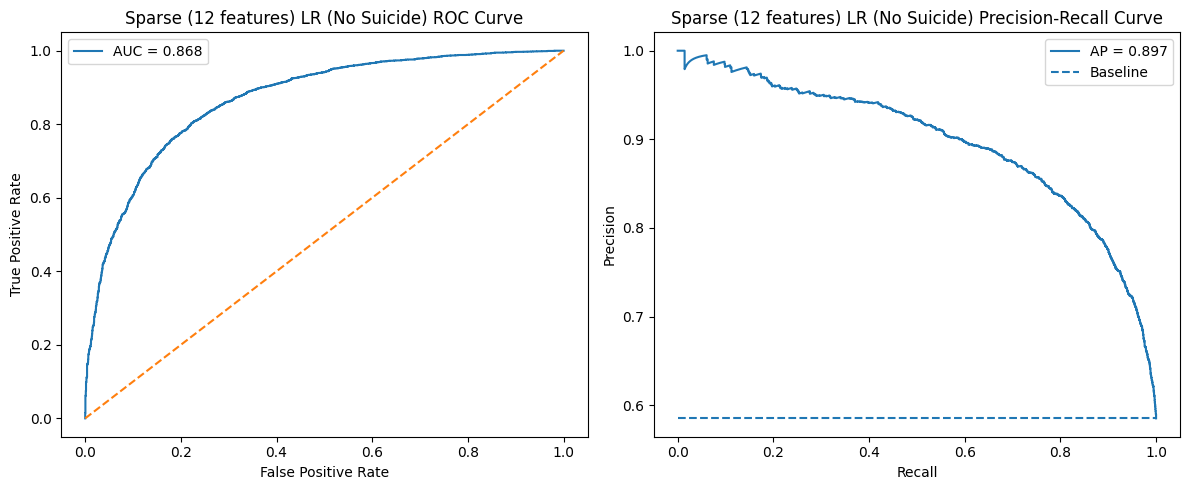


--- Top 10 Features Increasing Risk ---
                                  Feature  Coefficient
                   num__Academic Pressure     1.054856
            cat__Dietary Habits_Unhealthy     0.809042
                    num__Financial Stress     0.726610
                    num__Work/Study Hours     0.412620
    cat__Sleep Duration_Less than 5 hours     0.268275
             cat__Dietary Habits_Moderate     0.255773
cat__Family History of Mental Illness_Yes     0.122125
                   num__Pressure_x_Stress     0.081351
                                num__CGPA     0.046849
             num__Pressure_x_Satisfaction     0.000000

--- Top 10 Features Decreasing Risk ---
                              Feature  Coefficient
                      cat__Degree_MBA     0.000000
                  cat__Degree_M.Pharm     0.000000
                   cat__Degree_Others     0.000000
                      cat__Degree_MSc     0.000000
                       cat__Degree_ME     0.000000
       

In [66]:
TUNE_C = True
DEFAULT_C = 0.02

if TUNE_C:
    # Build the base LR model to evaluate C values
    base_log_reg = LogisticRegression(
        penalty="l1",
        solver="saga",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    )

    # Test all values of C using 5-fold cross validation (ROC-AUC) to evaluate
    hyper_parameter_grid = {
        'C': np.linspace(0.001, 0.5, 50)
    }
    grid_search = GridSearchCV(
        estimator=base_log_reg,
        param_grid=hyper_parameter_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    print("Running Hyperparameter Tuning...")
    grid_search.fit(X_train_processed_no_suicide, y_train)

    # Keep the best model
    results = pd.DataFrame(grid_search.cv_results_)
    best_index = results['mean_test_score'].idxmax()
    best_score = results.loc[best_index, 'mean_test_score']

    acceptable_threshold = best_score - results['std_test_score']

    # Choose the simplest model within the acceptable threshold
    good_models = results[results["mean_test_score"] >= acceptable_threshold]
    optimal_C = good_models['param_C'].astype(float).min()
    print(f"Optimal 'C' within margin: {optimal_C:.4f}")
    plot_gridsearch_param(grid_search, "C", selected_value=optimal_C, use_log_scale=False)
    
else:
    # If tuning is disabled, use value from testing
    optimal_C = DEFAULT_C

# Now, train a model with the optimal C
log_reg_no_suicide = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=optimal_C,
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
log_reg_no_suicide.fit(X_train_processed_no_suicide, y_train)

# Evaluate sparsity after Lasso
num_features = evaluate_sparsity(log_reg_no_suicide)

# Do cross-validation to check consistency
cv_scores = cross_validate_model(log_reg_no_suicide, X_train_processed_no_suicide, y_train, cv=5, name=f"Sparse ({num_features} features) LR (No Suicide)")

# Find the best threshold for evaluation (Used to weight TP/FN)
y_proba_test = log_reg_no_suicide.predict_proba(X_test_processed_no_suicide)[:, 1]
threshold_result = find_best_threshold(y_test, y_proba_test, target_recall=0.90)  # Catch 90% of true positives (avoid false negatives)
print(f"Threshold Details: (Threshold = {threshold_result["threshold"]:.4f} | Precision = {threshold_result["precision"]:.4f} | Recall = {threshold_result["recall"]:.4f}")

# Evaluate the model
evaluate_model(log_reg_no_suicide, X_test_processed_no_suicide, y_test, f"Sparse ({num_features} features) LR (No Suicide)", threshold=threshold_result["threshold"])

# Rank features by importance
show_feature_importance(log_reg_no_suicide, preprocessor_no_suicide)

# Deep Learning

## Tools

In [67]:
import copy

def train_model(model, train_loader, val_loader, optimizer, criterion, lr_scheduler, params):
    """Train the provided model using the provided training and validation data (+params for other variables)"""
    
    best_val_loss = float('inf')
    best_model_wts = None
    patience = params.get("patience", 10)
    counter = 0
    
    for epoch in range(100):
        model.train()
        running_train_loss = 0.0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()
        
        avg_train_loss = running_train_loss / len(train_loader)
            
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_vx, batch_vy in val_loader:
                outputs = model(batch_vx)
                val_loss += criterion(outputs, batch_vy).item()
        
        avg_val_loss = val_loss / len(val_loader)

        lr_scheduler.step(avg_val_loss)
        
        print(f"Epoch [{epoch+1:2d}/100] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # Early Stopping Logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"\n--- Early Stopping Triggered! ---")
                print(f"No improvement for {patience} consecutive epochs.")
                break
                
    if best_model_wts:
        model.load_state_dict(best_model_wts)
    
    return model


## Data Pre-Processing

In [68]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import copy

# Create the validation set (split the training set again)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_processed_no_suicide, 
    y_train, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train
)

def to_tensor(data):
    if hasattr(data, "toarray"): data = data.toarray()
    return torch.tensor(data, dtype=torch.float32)

# Convert to tensors
X_train_t = to_tensor(X_train_final)
y_train_t = torch.tensor(y_train_final.values, dtype=torch.float32).view(-1, 1)
X_val_t = to_tensor(X_val)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

# Build data loaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)

print(f"Data ready. Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Data ready. Train batches: 279 | Val batches: 70


## Multi-Layer Perceptron

In [69]:
class StudentDepressionMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout_rate):
        super(StudentDepressionMLP, self).__init__()
        layers = []
        in_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, 1))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

# Build the model, and select an optimizer (for learning rate) and a criterion to check
params = {
    'hidden': [128, 64], 
    'dropout': 0.3, 
    'lr': 0.001, 
    'wd': 1e-5,
    'patience': 10
}
model = StudentDepressionMLP(input_dim=X_train_t.shape[1], hidden_dims=params["hidden"], dropout_rate=params["dropout"])
optimizer = optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["wd"])
criterion = nn.BCELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)


In [70]:
# Train the model (with early stopping)
model = train_model(model, train_loader, val_loader, optimizer, criterion, scheduler, params)

Epoch [ 1/100] | Train Loss: 0.4738 | Val Loss: 0.4361
Epoch [ 2/100] | Train Loss: 0.4451 | Val Loss: 0.4382
Epoch [ 3/100] | Train Loss: 0.4435 | Val Loss: 0.4347
Epoch [ 4/100] | Train Loss: 0.4388 | Val Loss: 0.4370
Epoch [ 5/100] | Train Loss: 0.4383 | Val Loss: 0.4336
Epoch [ 6/100] | Train Loss: 0.4366 | Val Loss: 0.4351
Epoch [ 7/100] | Train Loss: 0.4344 | Val Loss: 0.4351
Epoch [ 8/100] | Train Loss: 0.4331 | Val Loss: 0.4361
Epoch [ 9/100] | Train Loss: 0.4289 | Val Loss: 0.4347
Epoch [10/100] | Train Loss: 0.4296 | Val Loss: 0.4349
Epoch [11/100] | Train Loss: 0.4274 | Val Loss: 0.4350
Epoch [12/100] | Train Loss: 0.4266 | Val Loss: 0.4350
Epoch [13/100] | Train Loss: 0.4262 | Val Loss: 0.4364
Epoch [14/100] | Train Loss: 0.4249 | Val Loss: 0.4355
Epoch [15/100] | Train Loss: 0.4229 | Val Loss: 0.4360

--- Early Stopping Triggered! ---
No improvement for 10 consecutive epochs.



--- Deep Learning MLP Classification Report ---
              precision    recall  f1-score   support

           0       0.78      0.70      0.74      2310
           1       0.80      0.86      0.83      3258

    accuracy                           0.79      5568
   macro avg       0.79      0.78      0.78      5568
weighted avg       0.79      0.79      0.79      5568

ROC-AUC: 0.8674
Brier Score: 0.1446
MCC: 0.5706


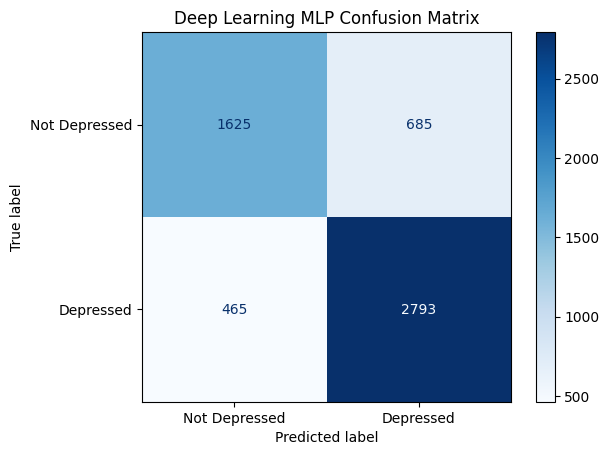

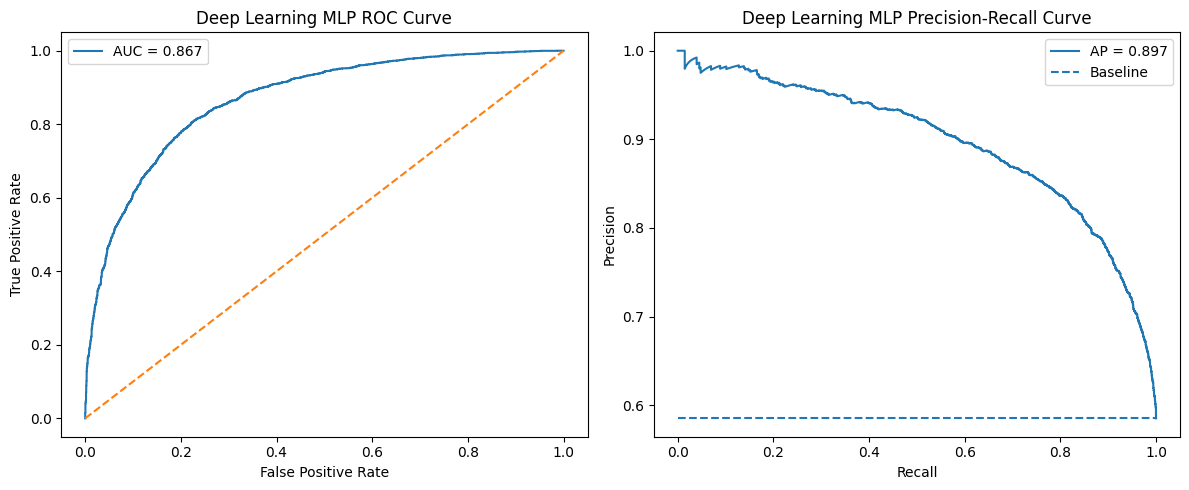

{'Model': 'Deep Learning MLP',
 'ROC-AUC': 0.867385709236538,
 'Brier_Score': 0.14458400011062622,
 'Accuracy': 0.7934626436781609,
 'Precision': 0.8030477285796435,
 'Recall': 0.8572744014732965,
 'F1_Score': 0.8292755344418052,
 'MCC': 0.5705625734857601,
 'AP': 0.896587860776747}

In [71]:
evaluate_model(
    model=model, 
    X_test=X_test_processed_no_suicide, 
    y_test=y_test, 
    name="Deep Learning MLP",
    threshold=0.5
)

# K-Nearest Neighbors (KNN)

Starting Grid Search for KNN...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

--- Grid Search Results ---
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 41, 'weights': 'distance'}
Best Cross-Validation AUC: 0.9018

--- Optimized KNN Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.72      0.77      2310
           1       0.82      0.90      0.86      3258

    accuracy                           0.82      5568
   macro avg       0.83      0.81      0.81      5568
weighted avg       0.82      0.82      0.82      5568

ROC-AUC: 0.9007
Brier Score: 0.1248
MCC: 0.6343


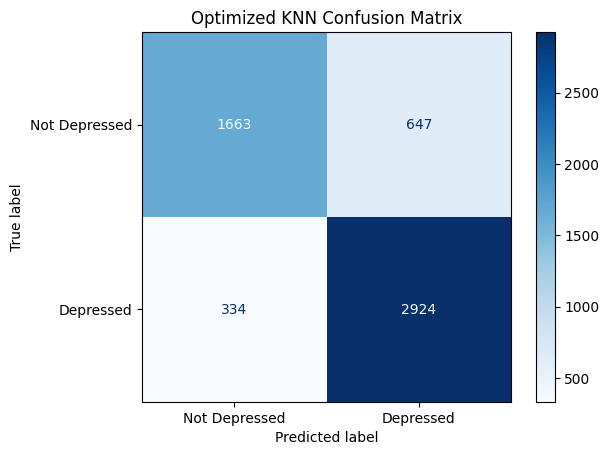

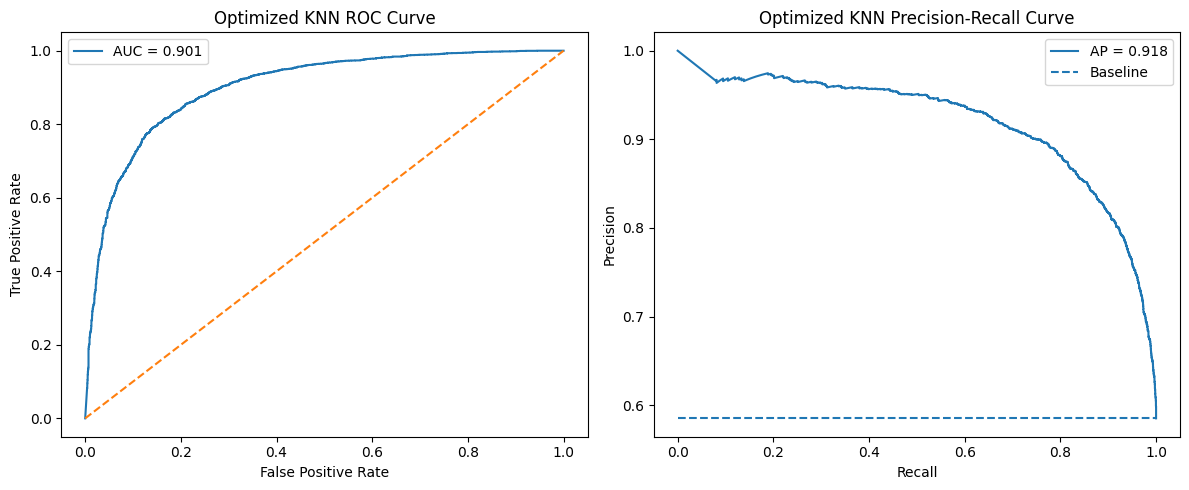

Misclassification Error Rate: 0.1762


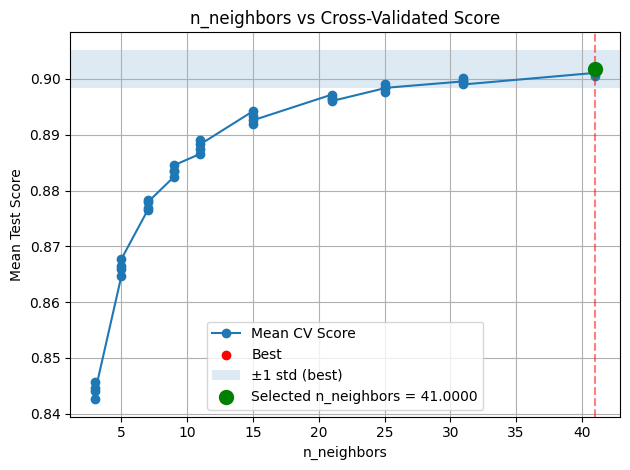

In [72]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

#Initialize the base model
knn = KNeighborsClassifier()

# Define the hyperparameter grid
# We use odd numbers for n_neighbors to prevent tie-breaking issues.
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 25, 31, 41],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Set up GridSearchCV
# We use scoring='roc_auc' because we decided AUC-ROC is our best metric for this medical/imbalanced context
print("Starting Grid Search for KNN...")
grid_search_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring='roc_auc',   # Optimizing for Area Under the ROC Curve
    n_jobs=-1,           # Use all available CPU cores to speed up processing
    verbose=1            # Gives a little output so you know it's working
)

# Fit the model on the processed training data
grid_search_knn.fit(X_train_processed, y_train)

# Extract the best model
best_knn = grid_search_knn.best_estimator_

print("\n--- Grid Search Results ---")
print(f"Best Parameters: {grid_search_knn.best_params_}")
print(f"Best Cross-Validation AUC: {grid_search_knn.best_score_:.4f}")

# Evaluate using the custom function
# This will output your classification report, confusion matrix, ROC, and PR curves
knn_metrics = evaluate_model(
    model=best_knn, 
    X_test=X_test_processed, 
    y_test=y_test, 
    name="Optimized KNN", 
    show_plots=True
)

misclassification_rate = 1 - knn_metrics["Accuracy"]
print(f"Misclassification Error Rate: {misclassification_rate:.4f}")



# Visualize the hyperparameter tuning using the plotting function
# Note: use_log_scale=False is better here since n_neighbors scales linearly
plot_gridsearch_param(
    grid_search=grid_search_knn, 
    param_name="n_neighbors", 
    use_log_scale=False,
    selected_value=grid_search_knn.best_params_['n_neighbors']
)

### Feature Importance for KNN

In [73]:
"""
In order to determine which features the KNN model relied the most on we can use a model-agnostic technique called Permutation Importance.
Essentially it works by randomly shuffling the values of the features until they become total garbage, and seeing how much the model's AUC drops. If the AUC model drops massively, that feature was highly important.
"""
from sklearn.inspection import permutation_importance
import pandas as pd

print("Calculating KNN Permutation Importance...")

# Calculate permutation importance using our best metric (AUC)
perm_results = permutation_importance(
    estimator=best_knn, 
    X=X_test_processed, 
    y=y_test, 
    scoring='roc_auc', 
    n_repeats=5,       # Shuffles each column 5 times for increased stability
    random_state=42, 
    n_jobs=-1
)

# Get the feature names from your preprocessor
feature_names = preprocessor.get_feature_names_out()

# Create a clean dataframe to view the results
knn_importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance_Drop": perm_results.importances_mean
})

# Sort to see the most critical features at the top
knn_importances = knn_importances.sort_values(by="Importance_Drop", ascending=False)

print("\n--- Top 10 Features Driving KNN Predictions ---")
print(knn_importances.head(10).to_string(index=False))

Calculating KNN Permutation Importance...

--- Top 10 Features Driving KNN Predictions ---
                                       Feature  Importance_Drop
cat__Have you ever had suicidal thoughts ?_Yes         0.062563
                                      num__Age         0.010930
                         num__Work/Study Hours         0.010292
                 cat__Dietary Habits_Unhealthy         0.007287
                       num__Study Satisfaction         0.004753
                        num__Academic Pressure         0.004685
                         num__Financial Stress         0.003936
     cat__Family History of Mental Illness_Yes         0.001895
                                     num__CGPA         0.000783
                              cat__Gender_Male         0.000740


C:\Users\archa\AppData\Local\Temp\ipykernel_21460\3158833710.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


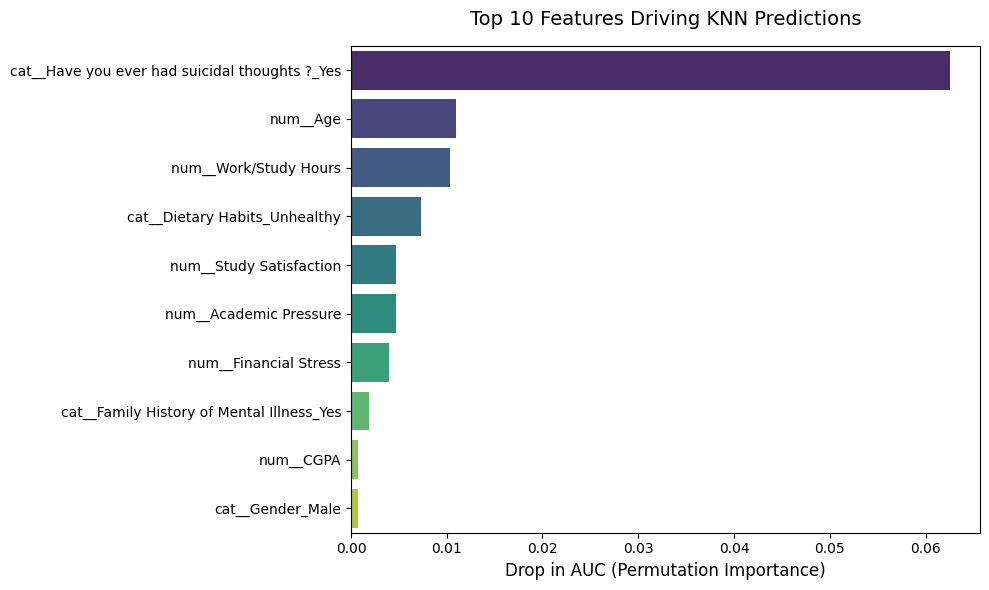

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using the 'knn_importances' dataframe we created earlier
plt.figure(figsize=(10, 6))
# Plot only the top 10 to keep the slide clean
sns.barplot(
    x="Importance_Drop", 
    y="Feature", 
    data=knn_importances.head(10), 
    palette="viridis"
)

plt.title("Top 10 Features Driving KNN Predictions", fontsize=14, pad=15)
plt.xlabel("Drop in AUC (Permutation Importance)", fontsize=12)
plt.ylabel("") # Hide the 'Feature' label since it's obvious
plt.tight_layout()
plt.show()

### PCA Decision Boundary Graph

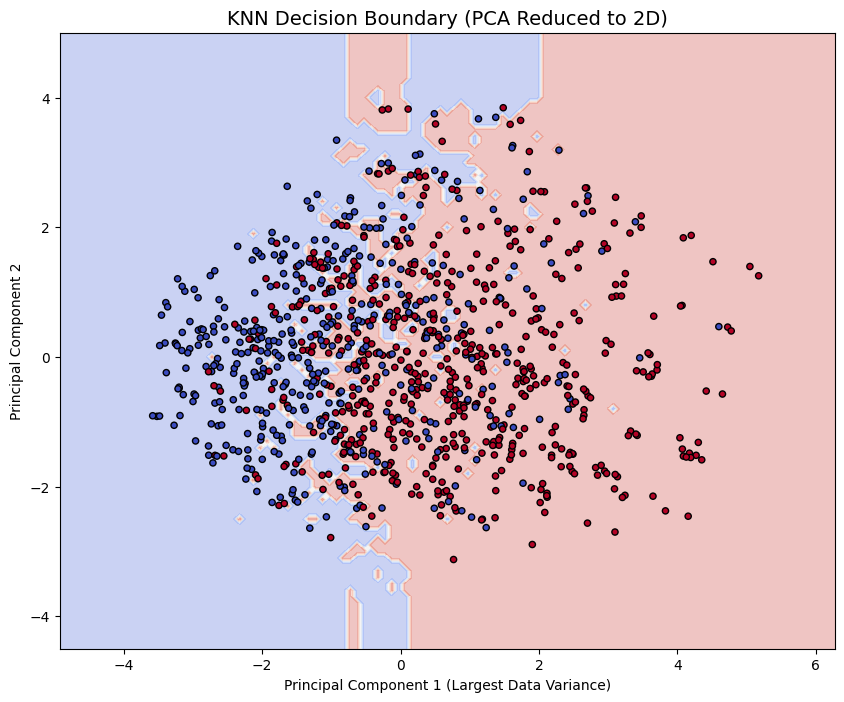

In [75]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# 1. Squash the 46D data down to 2D using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_processed)

# 2. Train a quick KNN specifically on this 2D data using the best parameters
knn_2d = KNeighborsClassifier(n_neighbors=41, weights='distance', metric='manhattan')
knn_2d.fit(X_train_pca, y_train)

# 3. Create a mesh grid to draw the background colors
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predict the class for every point on that grid
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Plot it
plt.figure(figsize=(10, 8))
cmap_light = ListedColormap(['#lightblue', '#lightcoral'])
cmap_bold = ListedColormap(['#0000FF', '#FF0000'])

# Draw the boundary regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

# Plot a sample of the actual students (plotting all 27k is too messy)
# We will just plot 1000 random students so the visual is clean
sample_idx = np.random.choice(X_train_pca.shape[0], 1000, replace=False)
plt.scatter(
    X_train_pca[sample_idx, 0], 
    X_train_pca[sample_idx, 1], 
    c=y_train.iloc[sample_idx], 
    cmap="coolwarm", 
    edgecolor='k', 
    s=20
)

plt.title("KNN Decision Boundary (PCA Reduced to 2D)", fontsize=14)
plt.xlabel("Principal Component 1 (Largest Data Variance)")
plt.ylabel("Principal Component 2")
plt.show()

# Tree-Based Methods

## Single Decision Tree

Single Decision tree

--- Decision Tree (Depth 4) Classification Report ---
              precision    recall  f1-score   support

           0       0.75      0.84      0.79      2310
           1       0.88      0.81      0.84      3258

    accuracy                           0.82      5568
   macro avg       0.82      0.82      0.82      5568
weighted avg       0.83      0.82      0.82      5568

ROC-AUC: 0.8917
Brier Score: 0.1274
MCC: 0.6385


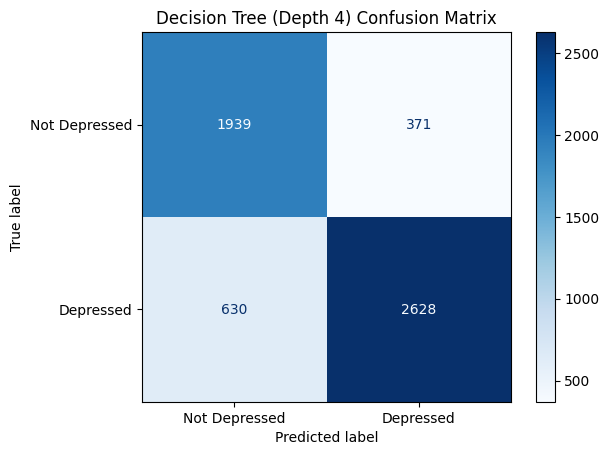

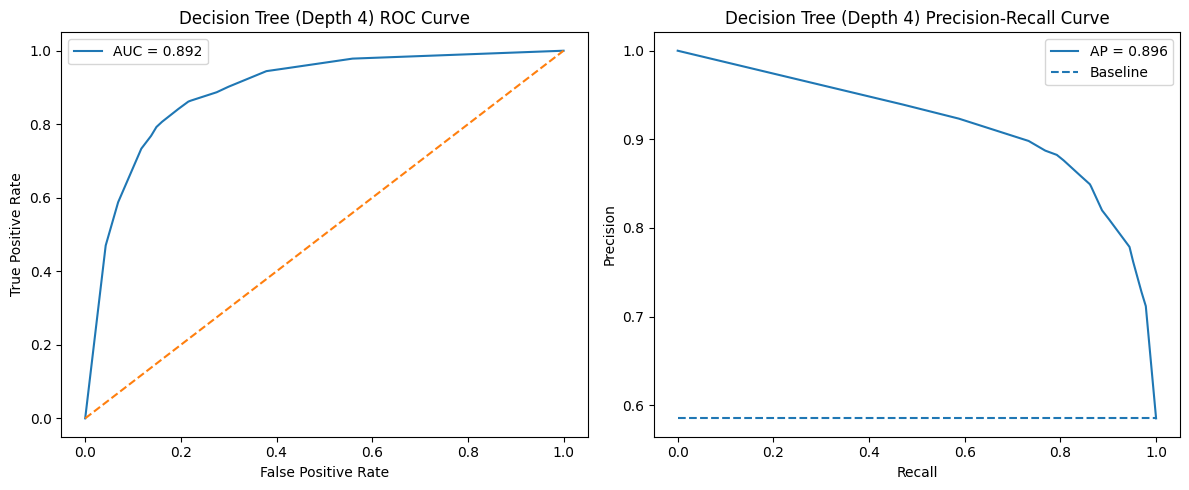

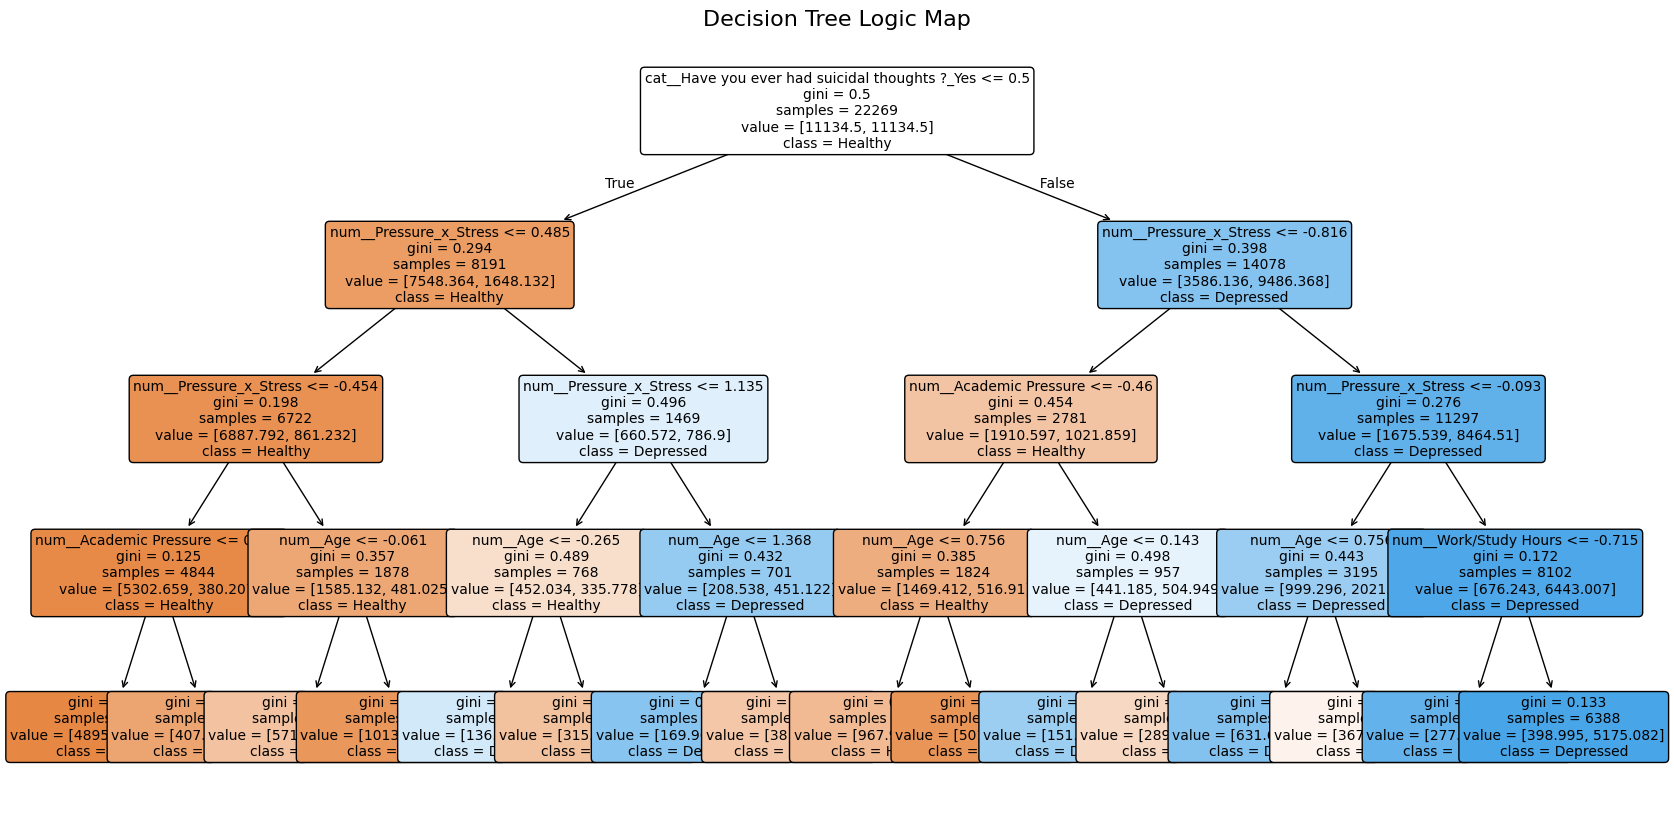

In [79]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import matplotlib.pyplot as plt
import pandas as pd

print("="*50)
print("Single Decision tree")
print("="*50)
# We limit max_depth to 4 so it doesn't overfit and we can actually visualize it
dt_model = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42)
dt_model.fit(X_train_processed, y_train)

evaluate_model(dt_model, X_test_processed, y_test, name="Decision Tree (Depth 4)")

# Let's actually draw the tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model, 
    feature_names=preprocessor.get_feature_names_out(), 
    class_names=["Healthy", "Depressed"], 
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("Decision Tree Logic Map", fontsize=16)
plt.show()

## Random Forest (Bagging)


Random Forest

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.80      0.81      0.81      2310
           1       0.87      0.86      0.86      3258

    accuracy                           0.84      5568
   macro avg       0.83      0.84      0.84      5568
weighted avg       0.84      0.84      0.84      5568

ROC-AUC: 0.9163
Brier Score: 0.1150
MCC: 0.6705


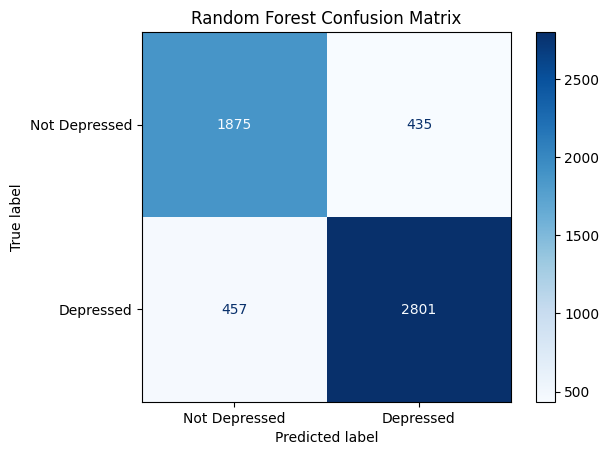

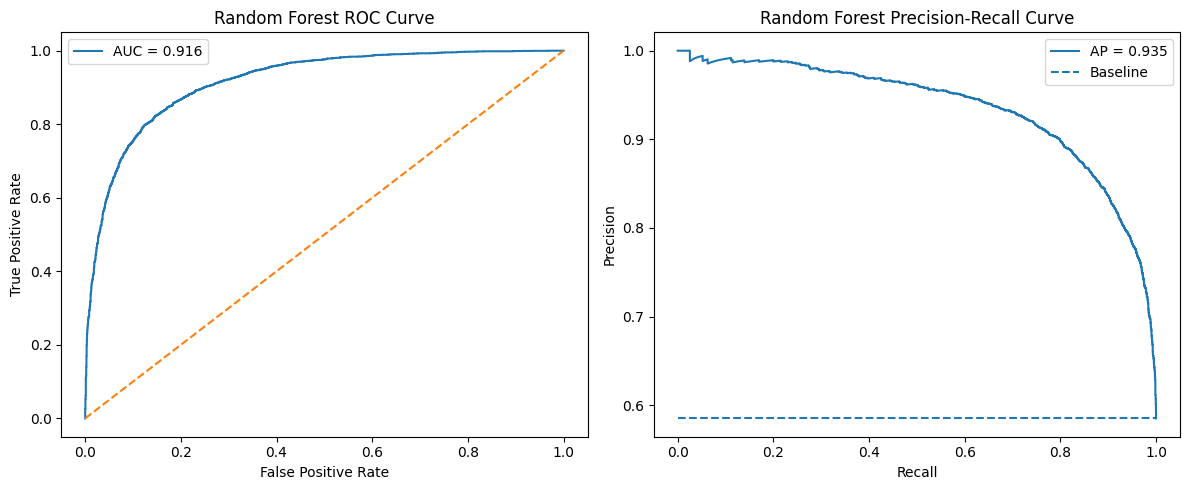

{'Model': 'Random Forest',
 'ROC-AUC': 0.9163202665965097,
 'Brier_Score': 0.11499836048868482,
 'Accuracy': 0.8397988505747126,
 'Precision': 0.86557478368356,
 'Recall': 0.8597298956414978,
 'F1_Score': 0.8626424391746227,
 'MCC': 0.6705113204318437,
 'AP': 0.9354332379921395}

In [80]:
print("\n" + "="*50)
print("Random Forest")
print("="*50)
# Bagging builds hundreds of independent trees on random subsets of data and averages their votes
rf_model = RandomForestClassifier(
    n_estimators=150,      # Build 150 different trees
    max_depth=12,          # Let them grow fairly deep
    class_weight="balanced", 
    n_jobs=-1,             # Use all CPU cores
    random_state=42
)
rf_model.fit(X_train_processed, y_train)

evaluate_model(rf_model, X_test_processed, y_test, name="Random Forest")

## Gradient Boosting


Gradient Boosting

--- Gradient Boosting Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.79      0.80      2310
           1       0.85      0.88      0.87      3258

    accuracy                           0.84      5568
   macro avg       0.84      0.83      0.84      5568
weighted avg       0.84      0.84      0.84      5568

ROC-AUC: 0.9189
Brier Score: 0.1109
MCC: 0.6725


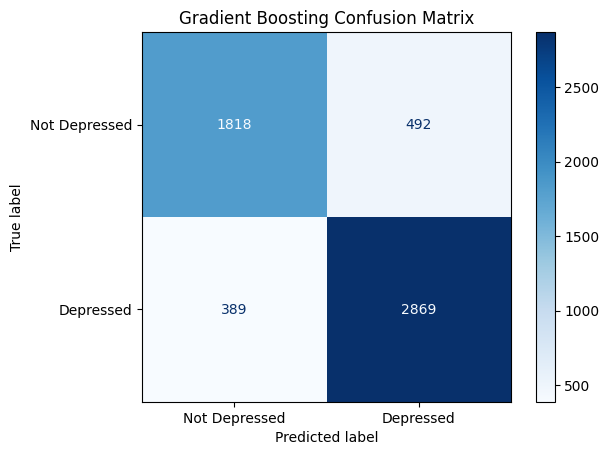

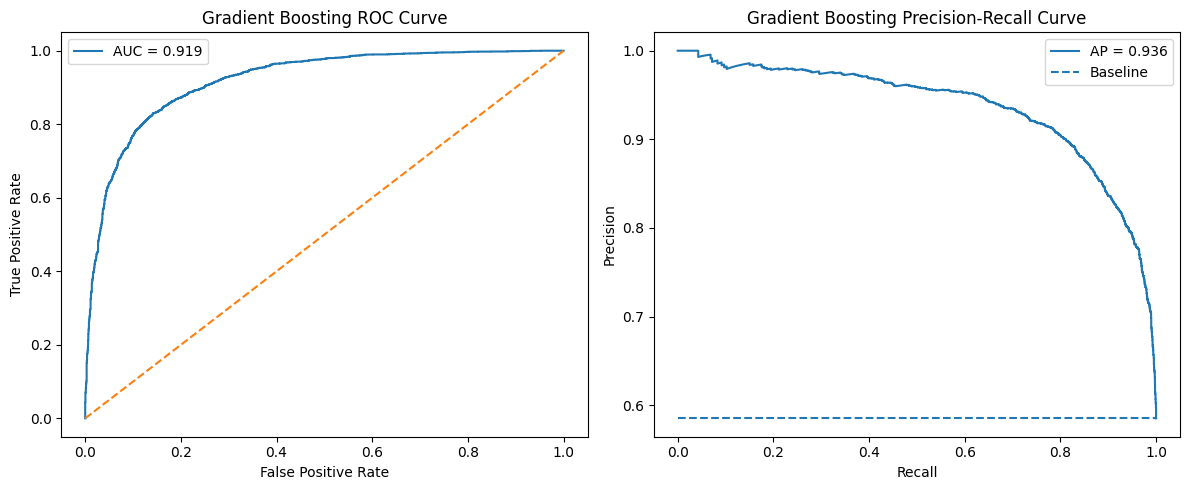


Feature Importances
Top 10 Most Important Features (Gradient Boosting):
                                       Feature Importance
cat__Have you ever had suicidal thoughts ?_Yes     46.11%
                        num__Pressure_x_Stress     27.64%
                                      num__Age      5.51%
                        num__Academic Pressure      4.66%
                         num__Work/Study Hours      3.71%
                 cat__Dietary Habits_Unhealthy      2.37%
                                     num__CGPA       2.1%
                       num__Study Satisfaction      1.65%
                  num__Pressure_x_Satisfaction      0.83%
                           num__Stress_x_Sleep      0.62%


In [81]:
print("\n" + "="*50)
print("Gradient Boosting")
print("="*50)
# Boosting builds trees sequentially. Each new tree specifically tries to fix the errors of the previous tree.
gb_model = GradientBoostingClassifier(
    n_estimators=150, 
    learning_rate=0.1,     # How much each tree contributes
    max_depth=5,           # Boosted trees should be shallow (weak learners)
    random_state=42
)
gb_model.fit(X_train_processed, y_train)

evaluate_model(gb_model, X_test_processed, y_test, name="Gradient Boosting")


print("\n" + "="*50)
print("Feature Importances")
print("="*50)
# Extracting feature importances from the top performing Gradient Boosting model
tree_importances = pd.DataFrame({
    "Feature": preprocessor.get_feature_names_out(),
    "Importance": gb_model.feature_importances_
})

# Sort and format
tree_importances = tree_importances.sort_values(by="Importance", ascending=False)
tree_importances["Importance"] = (tree_importances["Importance"] * 100).round(2).astype(str) + "%"

print("Top 10 Most Important Features (Gradient Boosting):")
print(tree_importances.head(10).to_string(index=False))

# Discriminant Analysis

In [83]:
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

## Data Pre-Processing



Just as we observed in previous analyses, leaving variables like `'Have you ever had suicidal thoughts ?'` in the dataset constitutes **Data Leakage**. It is highly correlated with depression and prevents the model from uncovering systemic causes (like academic pressure or financial stress). We will explicitly remove it.

In [85]:
categorical_features_no_suicide = categorical_features.copy()
categorical_features_no_suicide.remove('Have you ever had suicidal thoughts ?')

X_train_no_suicide = X_train.drop(columns=["Have you ever had suicidal thoughts ?"])
X_test_no_suicide = X_test.drop(columns=["Have you ever had suicidal thoughts ?"])

preprocessor_no_suicide = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features_no_suicide)
    ]
)
 
X_train_processed_no_suicide = preprocessor_no_suicide.fit_transform(X_train_no_suicide)
X_test_processed_no_suicide = preprocessor_no_suicide.transform(X_test_no_suicide)
print(f"Pre-Processing Complete. Features formulated: {X_train_processed_no_suicide.shape[1]}")

Pre-Processing Complete. Features formulated: 44


## Linear Discriminant Analysis (LDA)


LDA assumes that features are normally distributed and that all classes share the exact same covariance matrix. Instead of merely looking at accuracy, we want to know *which* features LDA is actually utilizing to discriminate between a depressed and non-depressed student.

In [86]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_processed_no_suicide, y_train)

# Predictions and Accuracy
lda_pred = lda.predict(X_test_processed_no_suicide)
print(f"LDA Base Accuracy: {accuracy_score(y_test, lda_pred):.4f}")

LDA Base Accuracy: 0.7958


### Feature Importance via LDA Coefficients

Because LDA creates a linear decision boundary, the coefficients of its discriminant directly correspond to feature importance (similar to Logistic Regression or Lasso). Let's plot the top determining factors.

                                 Feature  Coefficient
0                                    Age    -0.598745
1                      Academic Pressure     1.573998
2                                   CGPA     0.081472
3                     Study Satisfaction    -0.268721
4                       Work/Study Hours     0.463013
5                       Financial Stress     1.162093
6                       Pressure_x_Sleep     0.115341
7                      Pressure_x_Stress    -0.488712
8                         Stress_x_Sleep     0.061378
9                Pressure_x_Satisfaction    -0.071085
10                           Gender_Male     0.003876
11              Sleep Duration_7-8 hours     0.015560
12      Sleep Duration_Less than 5 hours     0.533624
13      Sleep Duration_More than 8 hours    -0.505447
14               Dietary Habits_Moderate     0.563283
15              Dietary Habits_Unhealthy     1.135301
16                          Degree_B.Com    -0.047652
17                          

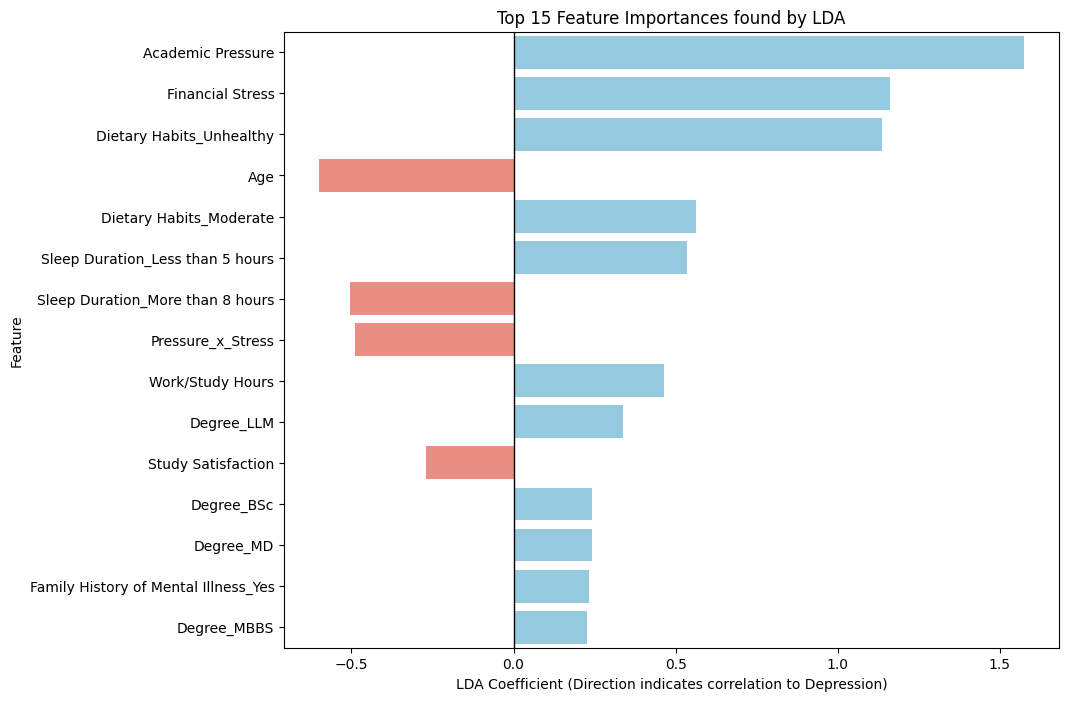

In [87]:
# Extract weights of the first (and only) linear discriminant for binary classification
feature_names = preprocessor_no_suicide.get_feature_names_out()
feature_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]
lda_coefs = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lda.coef_[0]
})
print(lda_coefs)

# Calculate absolute importance for sorting
lda_coefs['Absolute_Importance'] = lda_coefs['Coefficient'].abs()
lda_coefs = lda_coefs.sort_values(by='Absolute_Importance', ascending=False)

# Safely build the color palette as a Python list
colors = ['salmon' if x < 0 else 'skyblue' for x in lda_coefs['Coefficient'].head(15)]

# Plot Top 15 Features
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Coefficient', 
    y='Feature', 
    data=lda_coefs.head(15), 
    hue='Feature',
    palette=colors,
    legend=False
)
plt.title("Top 15 Feature Importances found by LDA")
plt.xlabel("LDA Coefficient (Direction indicates correlation to Depression)")
plt.ylabel("Feature")
plt.axvline(0, color='black', linewidth=1)
plt.show()

### Dimensionality Reduction and Visualizing the Decision Space

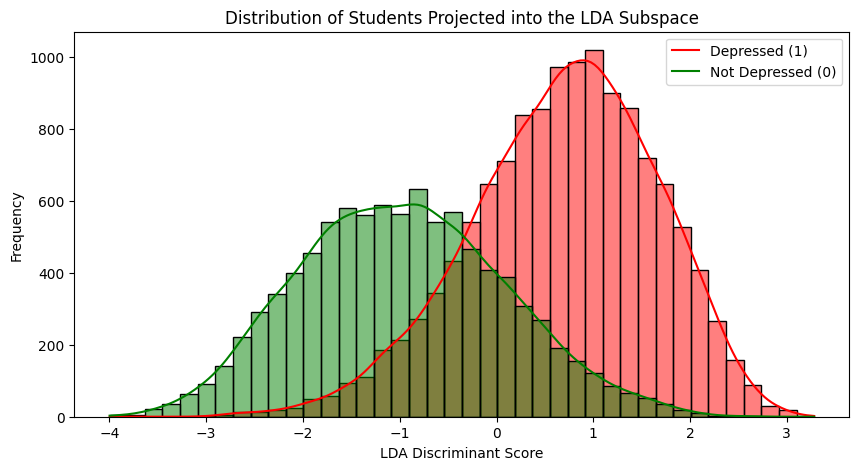

In [88]:
# Transform data into the 1D LDA space
X_train_lda = lda.transform(X_train_processed_no_suicide).flatten()

# Create a DataFrame for easiest plotting
lda_proj_df = pd.DataFrame({
    'LDA_Score': X_train_lda,
    'Actual_Depression': y_train
})

plt.figure(figsize=(10, 5))
sns.histplot(data=lda_proj_df, x='LDA_Score', hue='Actual_Depression', kde=True, bins=40, palette=['green', 'red'], alpha=0.5)
plt.title("Distribution of Students Projected into the LDA Subspace")
plt.xlabel("LDA Discriminant Score")
plt.ylabel("Frequency")
plt.legend(['Depressed (1)', 'Not Depressed (0)'])
plt.show()


### Evaluation


--- LDA Classification Report ---
              precision    recall  f1-score   support

           0       0.78      0.70      0.74      2310
           1       0.80      0.86      0.83      3258

    accuracy                           0.80      5568
   macro avg       0.79      0.78      0.79      5568
weighted avg       0.79      0.80      0.79      5568

ROC-AUC: 0.8680
Brier Score: 0.1444
MCC: 0.5753


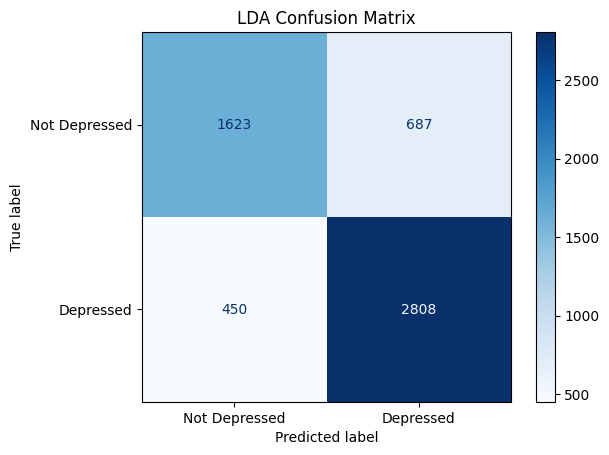

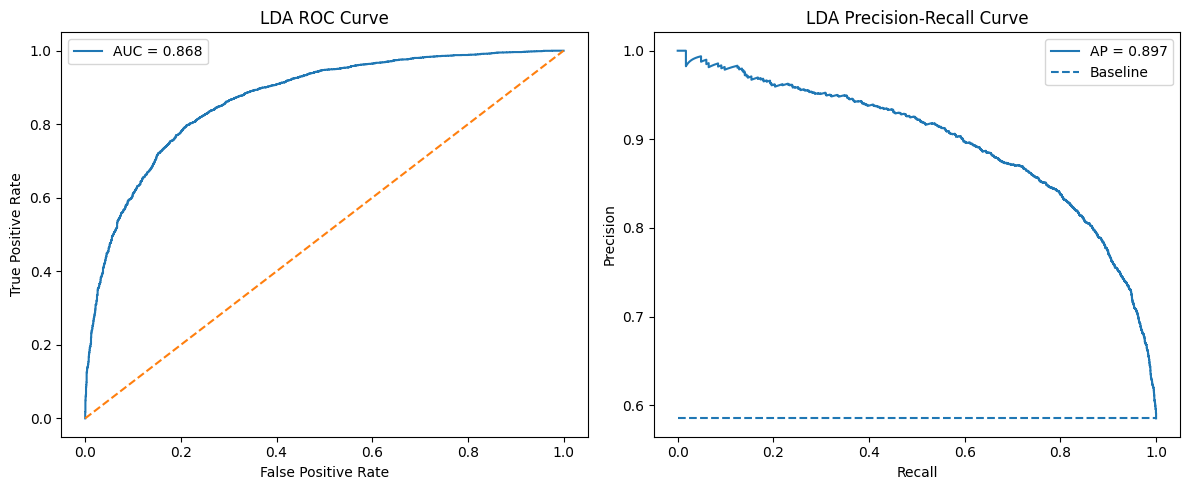

{'Model': 'LDA',
 'ROC-AUC': 0.8679674939343447,
 'Brier_Score': 0.14437810060204845,
 'Accuracy': 0.7957974137931034,
 'Precision': 0.8034334763948497,
 'Recall': 0.861878453038674,
 'F1_Score': 0.8316303864948912,
 'MCC': 0.5753123002495474,
 'AP': 0.896781485308898}

In [89]:
evaluate_model(lda, X_test_processed_no_suicide, y_test, "LDA")

## Quadratic Discriminant Analysis (QDA)

QDA relaxes the LDA constraint, allowing each class to have its own unique covariance matrix. This means it can capture complex feature interactions.

However, estimating multiple covariance matrices is highly susceptible to collinearity—especially when using sparse dummy variables. We will perform Grid Search to find the optimal `reg_param` (shrinkage) mathematically, preventing matrix singularity while tuning the model.

In [90]:
# Search for the optimal regularization parameter
qda_params = {
    'reg_param': [0.0001, 0.001, 0.01, 0.1, 0.3, 0.5, 0.8]
}

# 5-Fold Cross Validation tuning
qda_grid = GridSearchCV(QuadraticDiscriminantAnalysis(), qda_params, cv=5, scoring='accuracy')
qda_grid.fit(X_train_processed_no_suicide, y_train)

best_qda = qda_grid.best_estimator_

print(f"Optimal QDA Regularization Parameter (reg_param): {qda_grid.best_params_['reg_param']}")

# Final QDA Evaluation
qda_pred = best_qda.predict(X_test_processed_no_suicide)
print(f"Regularized QDA Accuracy: {accuracy_score(y_test, qda_pred):.4f}")


Optimal QDA Regularization Parameter (reg_param): 0.1
Regularized QDA Accuracy: 0.7901


### Evaluation


--- QDA Classification Report ---
              precision    recall  f1-score   support

           0       0.77      0.70      0.73      2310
           1       0.80      0.85      0.83      3258

    accuracy                           0.79      5568
   macro avg       0.79      0.78      0.78      5568
weighted avg       0.79      0.79      0.79      5568

ROC-AUC: 0.8576
Brier Score: 0.1551
MCC: 0.5635


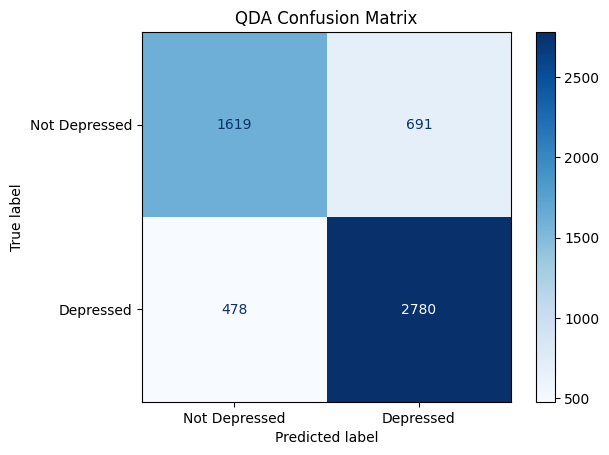

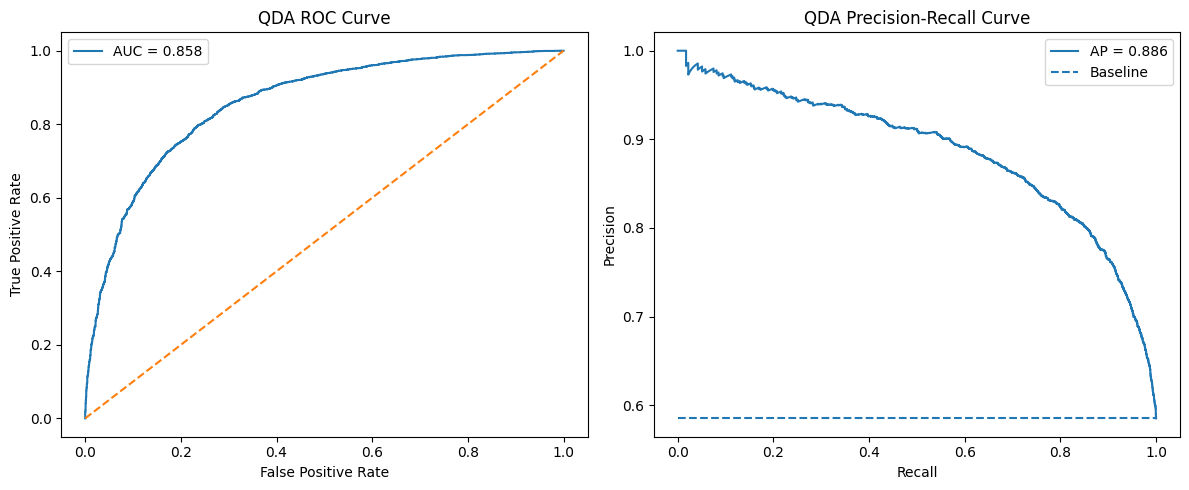

{'Model': 'QDA',
 'ROC-AUC': 0.8576445858213815,
 'Brier_Score': 0.1550948974275959,
 'Accuracy': 0.7900502873563219,
 'Precision': 0.8009219245174302,
 'Recall': 0.8532842234499693,
 'F1_Score': 0.8262743349680487,
 'MCC': 0.5634850063538477,
 'AP': 0.8863351705178468}

In [91]:
evaluate_model(best_qda, X_test_processed_no_suicide, y_test, "QDA")